In [1]:
import os, sys
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import lsstypes as types
import matplotlib.pyplot as plt

sys.path.append('../../')
from fit_tools import LikelihoodBuilder
from cat_tools import get_measurement_ready_fn, get_measurement_fn
from helper import REDSHIFT_BIN_TRACER, REDSHIFT_TEST_TRACER
%load_ext autoreload
%autoreload 2
%matplotlib inline

%load_ext autoreload
%autoreload 2

OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'
# save_fig=True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# KRANGES = {
#     'mesh2': [
#         {'ells': 0, 'k': [0.02, 0.300, 0.005]},
#         {'ells': 2, 'k': [0.02, 0.300, 0.005]},
#     ],
#     'mesh3': [
#         {'ells': (0, 0, 0), 'k': [0.02, 0.20, 0.005]},
#         {'ells': (2, 0, 2), 'k': [0.02, 0.08, 0.005]},
#     ],
# }

KRANGES = {
    'mesh2': [
        {'ells': 0, 'k': [0.02, 0.350, 0.005]},
        {'ells': 2, 'k': [0.02, 0.250, 0.005]},
    ],
    'mesh3': [
        {'ells': (0, 0, 0), 'k': [0.02, 0.20, 0.005]},
        {'ells': (2, 0, 2), 'k': [0.02, 0.03, 0.005]},
    ],
}

def build_observables(stats, theory_model='folpsD', prior_basis='physical_aap'):
    return [{'stat': {'kind': stat, 'select': KRANGES[stat]},
             'theory': {'model': theory_model, 'prior_basis': prior_basis},
            } for stat in stats]

In [6]:
tracer = 'LRG2'
zrange = REDSHIFT_BIN_TRACER[tracer]
stats=['mesh2', 'mesh3']


version = 'AbacusHF-v2'
if 'QSO' in tracer:
    domain = 'cutsky'
    hod = 'base_dv'
else:
    domain = 'altmtl'
    hod = 'base'

args = dict(
    stats=stats,

    catalog={
        'tracer': tracer,
        'zrange': zrange,
        'domain': domain,
        'version': version,
        'hod': hod,
        'mock_ids': range(25),
        'use_dv': False, # False, 'verr_nonparam'
        'z_evol': False,
    },
    covariance={
        'source': 'mock',
        'version': 'holi-v3',
        'domain': 'altmtl',
        'mock_ids': range(1000),
        'corrections': ['hartlap', 'percival'],
    },
    cache_dir = '/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/'
)

observables = build_observables(args['stats'], theory_model='folpsD', prior_basis='physical_aap')

In [7]:
builder = LikelihoodBuilder(**args, observables=observables)

In [8]:
data, _, cov = builder.get_data_stats(unpack=True)

[000027.57]  06-24 01:33  fit_tools                    INFO     Reading cached stats /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/prepared_stats/data_LRG2-z0.6-0.8-mean25-S2+LRG2-z0.6-0.8-mean25-S3-d6f17c92.h5.
[000027.59]  06-24 01:33  fit_tools                    INFO     Reading cached stats /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/prepared_stats/window_LRG2-z0.6-0.8-mean25-S2+LRG2-z0.6-0.8-mean25-S3-d6f17c92.h5.


[000027.93]  06-24 01:33  fit_tools                    INFO     Reading cached stats /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/prepared_stats/covariance_LRG2-z0.6-0.8-S2+LRG2-z0.6-0.8-S3+cov-mock-holi-v3-e8a91d44.h5.


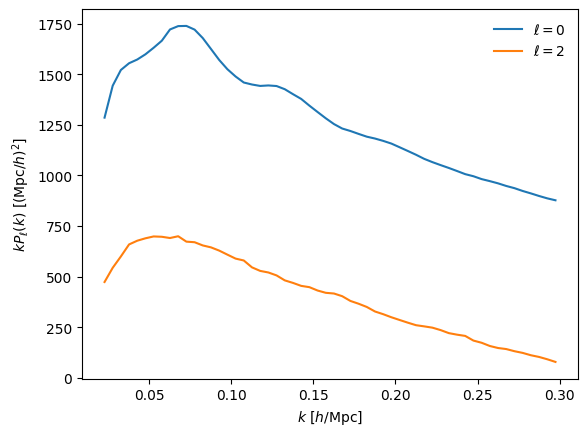

In [9]:
fig = data[0].plot()

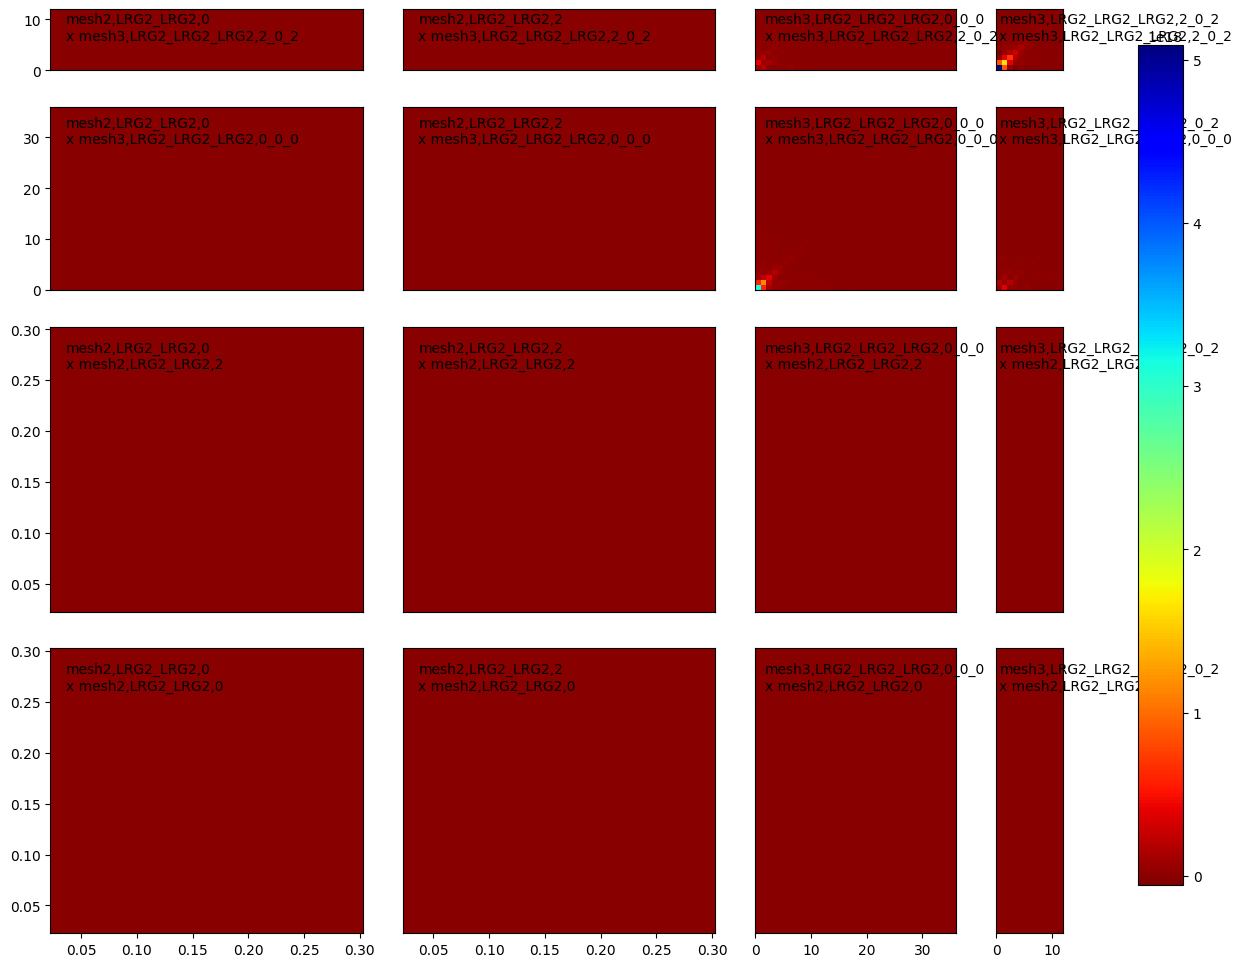

In [10]:
fig = cov.plot()

In [11]:
builder.get_redshift()

0.7058119286649192

In [12]:
likelihood = builder.get_likelihood()

[000043.42]  06-24 01:33  fit_tools                    INFO     Reading cached stats /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/prepared_stats/data_LRG2-z0.6-0.8-mean25-S2+LRG2-z0.6-0.8-mean25-S3-d6f17c92.h5.
[000043.44]  06-24 01:33  fit_tools                    INFO     Reading cached stats /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/prepared_stats/window_LRG2-z0.6-0.8-mean25-S2+LRG2-z0.6-0.8-mean25-S3-d6f17c92.h5.
[000043.76]  06-24 01:33  fit_tools                    INFO     Reading cached stats /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/prepared_stats/covariance_LRG2-z0.6-0.8-S2+LRG2-z0.6-0.8-S3+cov-mock-holi-v3-e8a91d44.h5.
[000043.87]  06-24 01:33  fit_tools                    WARNING  No redshift found in data attributes; read z=0.706 from the mesh2 window.
⚠️ No GPU found. Using JAX with CPU.
Calculating matrices (no save path specified)


/global/homes/s/shengyu/.conda/envs/fit_env/lib/python3.12/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


Calculating matrices (no save path specified)
[000055.24]  06-24 01:33  fit_tools                    INFO     Fitting emulator /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/test/_cache/emulator_cosmo-base_ns-fixed_taylor/emulator_LRG2-z0.6-0.8-mean25-S2-ell0-k0.02-0.30-0.005-ell2-k0.02-0.30-0.005-th-folpsD_8eb90200.npy
Calculating matrices (no save path specified)
[000061.79]  06-24 01:33  Emulator                     INFO     Varied parameters: ['h', 'omega_cdm', 'omega_b', 'logA'].
[000061.80]  06-24 01:33  Emulator                     INFO     Found varying ['H0', 'Omega_m', 'sigma8_m', 'sigma8', 'fsigma8', 'pt-jac', 'pt-kap', 'pt-muap', 'pt-table', 'pt-table_now', 'pt-scalars', 'pt-scalars_now', 'pt-qpar', 'pt-qper', 'pt-f', 'pt-f0', 'pt-pklir'] and fixed ['k', 'z', 'ells', 'wmu', 'kt', 'pt-A_full', 'pt-remove_DeltaP'] outputs.
[000062.76]  06-24 01:33  Differentiation              INFO     Varied parameters: ['h', 'omega_cdm', 'omega_b', 'logA'].
[000066.15]  

In [48]:
from desilike.profilers import MinuitProfiler
profiler = MinuitProfiler(likelihood, seed=42)
profile = profiler.maximize()

[001266.33]  06-23 01:49  MinuitProfiler               INFO     Varied parameters: ['h', 'omega_cdm', 'omega_b', 'logA', 'QSO1.b1p', 'QSO1.b2p', 'QSO1.bsp', 'QSO1.c1p', 'QSO1.c2p', 'QSO1.Pshotp', 'QSO1.Bshotp', 'QSO1.X_FoG_bp', 'QSO1.X_FoG_pp'].


[001274.72]  06-23 01:50  MinuitProfiler               INFO     Successfully jit input likelihood.


+-----------------------------------------+--------+---------+---------+
| chi2 / (160 - 18) = 100.05 / 142 = 0.70 | varied | bestfit |  error  |
+-----------------------------------------+--------+---------+---------+
|                    h                    |  True  |  0.663  |  0.023  |
|                omega_cdm                |  True  | 0.1088  | 0.0053  |
|                 omega_b                 |  True  | 0.02228 | 0.00056 |
|                  logA                   |  True  |  2.91   |  0.13   |
|                QSO1.b1p                 |  True  |  0.874  |  0.042  |
|                QSO1.b2p                 |  True  |  0.179  |  0.054  |
|                QSO1.bsp                 |  True  | -0.082  |  0.075  |
|                QSO1.c1p                 |  True  |  0.06   |  0.98   |
|                QSO1.c2p                 |  True  |  -2.3   |   6.4   |
|               QSO1.Pshotp               |  True  |  0.00   |  1.00   |
|               QSO1.Bshotp               |  True  

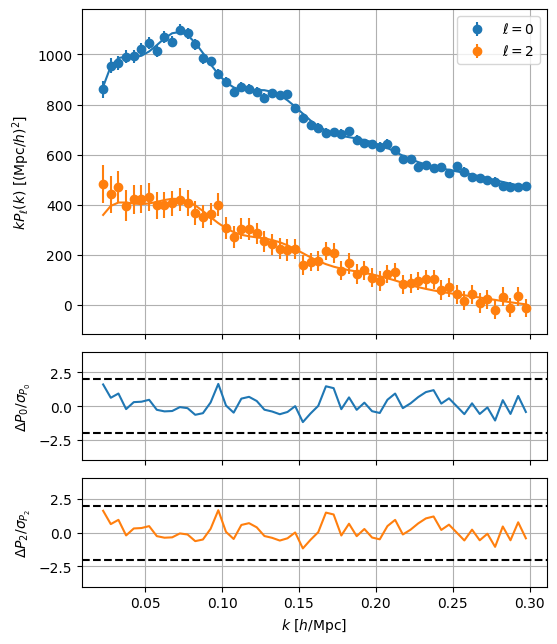

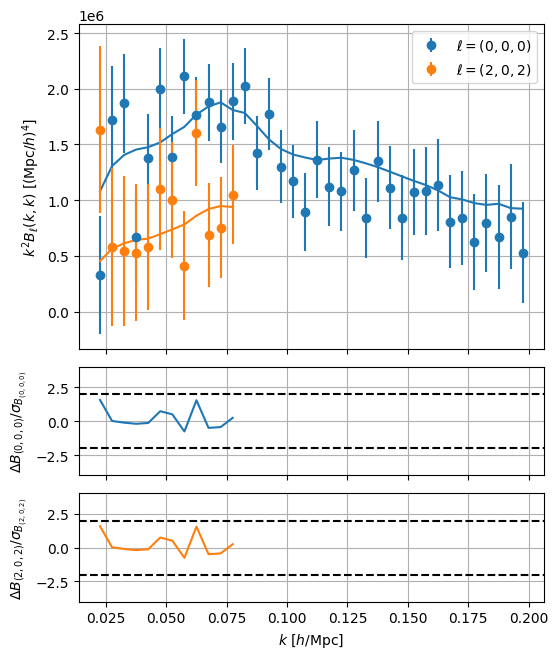

In [ ]:
print(profile.to_stats(tablefmt='pretty'))
print(-2*likelihood(**profile.bestfit.choice(input=True)))
observable = likelihood.observables
pk = observable[0].plot()
bk = observable[1].plot()

## corss-check with the direct read

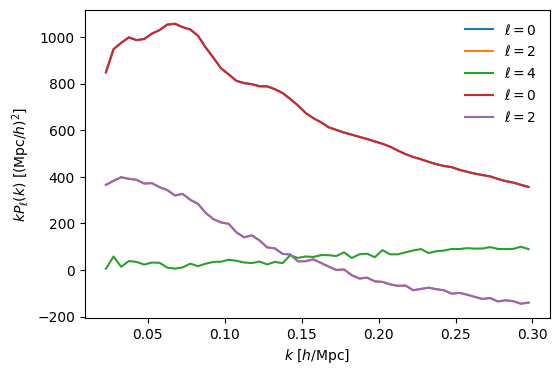

In [ ]:
data2 = []
for mock_id in mock_ids:
    fn = f'/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock{mock_id}/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_DR2_v2.0.h5'
    d = types.read(fn)
    sl = slice(0, None, 5)  # rebin to dk = 0.005 h/Mpc
    oklim = (0.02, 0.3)  # fitted k-range, no need to go to higher k
    d = d.select(k=sl).select(k=oklim)
    data2.append(d)

data2= types.mean(data2)
fig = plt.figure(figsize=(6, 4))
data2.plot(fig=fig)
data[0].plot(fig=fig)
plt.show()

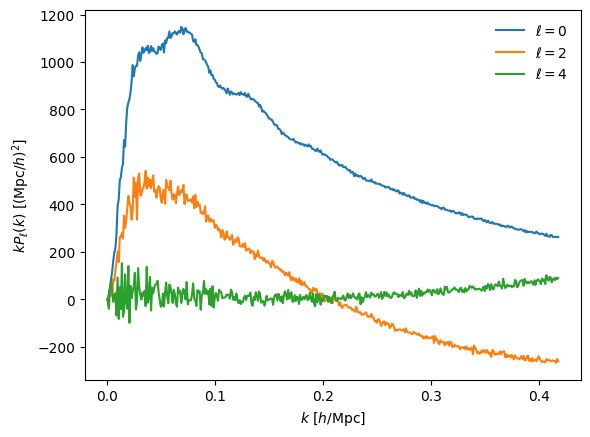

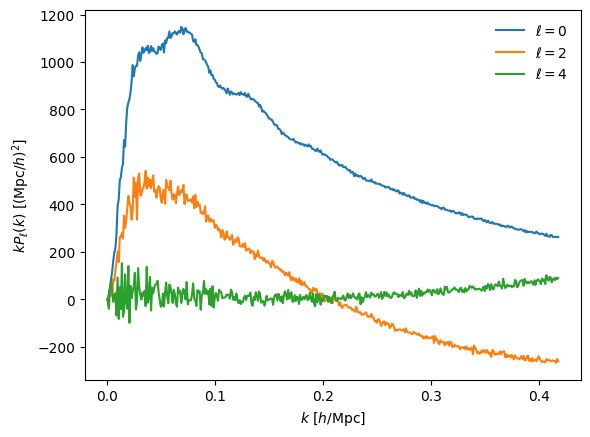

In [26]:
version = 'EZmocks-test' # EZmocks-test' 
tracer = 'QSO'
args = dict(version=version, tracer=tracer, zsnap=1.400, mock_id=1)
fn = get_measurement_ready_fn(**args)
a = types.read(fn.format('mesh2_spectrum_poles'))
a.plot()

None
